# The action agent, start to finish

This notebook walks through the final agent model from this repository —
the one that decides **where to move next** while reaching goals and
avoiding moving obstacles — and trains it from scratch on expert
demonstrations, then tests it and demonstrates its selection-history
signature.

It is the companion of `Visual-Search/tutorial_visual_search.ipynb`.
The two models share one theory — everything the agent senses, wants,
and remembers is written into a single spatial field, and one readout
selects the action — realized in two very different bodies:

| | visual search | action agent |
| --- | --- | --- |
| coordinate frame | retinotopic pixels | 360 rays around the agent |
| bottom-up source | color/shape contrast maps | obstacle sense (proximity + looming) |
| top-down source | goal-weighted color evidence | goal field (gain x cosine geometry) |
| history source | target/distractor memory traces | remembered goal-location field |
| readout | softmax over items -> a saccade | planner network -> a movement |

**Input and output.** Each step the agent receives: two consecutive
LiDAR scans (360 distances each), the vector to the visible goal, and
the vector to its remembered goal location. It returns a 2D movement.

**Before running:** generate the demonstrations once:

    python3 expert_goal.py --num_features 360 --num_episodes 20 \
      --max_steps_per_episode 3000 --record_every 5 --goal_free_steps 0 \
      --goal_bias none --output dataset/data_goal_unbiased_360.csv

Needs `numpy`, `pandas`, `matplotlib`, `torch`. The notebook loads the
pretrained checkpoint and precomputed results (Sections 6 and 7 read
recorded CSVs), so it runs in about a minute — only the Section 5
evaluation does live rollouts.

In [1]:
import math
import random
from types import SimpleNamespace

import numpy as np
import matplotlib.pyplot as plt
import torch

from model.goal_es2 import GoalEs2Model
from environment import (GOAL_RADIUS, CollisionTracker,
                                lidar_scan, make_world, sample_goal)

# publication style, matched to tutorial_visual_search.ipynb:
# despined axes, frameless legends, one shared palette
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.labelsize": 12, "axes.titlesize": 11, "font.size": 11,
    "legend.frameon": False, "legend.fontsize": 10,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "lines.linewidth": 1.6, "figure.dpi": 110,
})
C_ES2, C_MLP, C_TRF = "#2233aa", "#cc7722", "#118844"
C_GOAL, C_HAZARD, C_GRAY = "#118844", "#aa2222", "#888888"

torch.manual_seed(0)
random.seed(0)
W = H = 800

## 1. The model, with a diagram

The equation, in words. For each of 360 movement directions `q` around
the agent, the priority field is

    F(q) = f_S(S(q)) + f_G(G(q)) + f_H(H(q))
    movement = planner(F)

— the same three-term form as the search model's
`F(i) = w_S*S(i) + w_G*G(i) + w_H*H(i)` (salience, goal, history), now
over movement directions instead of display items:

- **`f_S(S(q))`** — the salience term: the obstacle sense, over a
  two-channel source `S = [proximity, looming]`.
- **`f_G(G(q))`** — the goal term: pull toward the visible goal.
- **`f_H(H(q))`** — the history term: pull toward remembered goal
  locations (carrying the strength scalar `beta_H`).

Every source flows into one ego-centered field; a small network reads
the field out as a movement. Two honest notes:

- **The channel maps are learned functions, not scalars.** In the
  search model each channel has one linear weight (`w_S`, `w_G`, `w_H`);
  the movement model generalizes each weight into a small learned
  function `f`: the goal and history fields a **gain-vs-distance curve**
  (a tiny MLP of distance), and the obstacle field a small **MLP over its
  two channels** (proximity and looming), with a learned per-ray
  sensitivity `k` in the front-end sigmoid. All three are the same kind
  of object — a learned transfer function from a physical variable to
  signal strength: the obstacle network transduces *physics* (distance,
  approach -> perceived urgency), the goal and history curves transduce
  *relevance* (distance -> pull). Comparing channels means comparing
  functions, not numbers.
- **There is no attention window here, and none in the search model
  either.** What the original ES2 paper called an "attention field" is
  the psychophysical transform above — part of building the sensory
  field, not a gate over a finished one. Recognizing that is what let
  the search model drop its window.

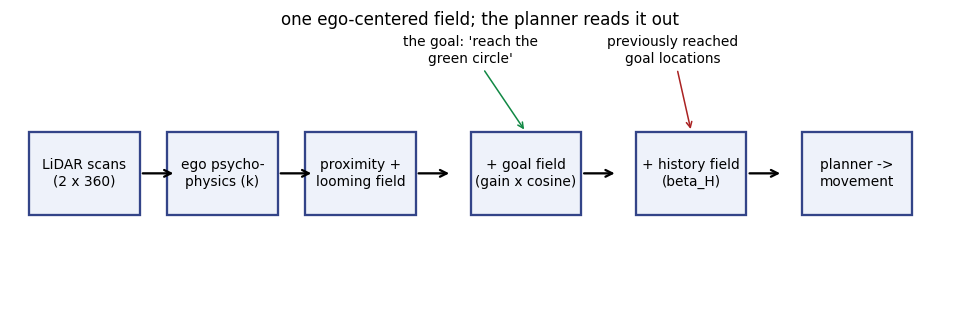

In [2]:
fig, ax = plt.subplots(figsize=(11, 3.2))
boxes = [(0.02, "LiDAR scans\n(2 x 360)"),
         (0.17, "ego psycho-\nphysics (k)"),
         (0.32, "proximity +\nlooming field"),
         (0.50, "+ goal field\n(gain x cosine)"),
         (0.68, "+ history field\n(beta_H)"),
         (0.86, "planner ->\nmovement")]
for x, label in boxes:
    ax.add_patch(plt.Rectangle((x, 0.35), 0.12, 0.32, fc="#eef2fa",
                               ec="#334488", lw=1.5))
    ax.text(x + 0.06, 0.51, label, ha="center", va="center", fontsize=9)
for x, _ in boxes[:-1]:
    ax.annotate("", xy=(x + 0.16, 0.51), xytext=(x + 0.12, 0.51),
                arrowprops=dict(arrowstyle="->", lw=1.5))
ax.annotate("the goal: 'reach the\ngreen circle'", xy=(0.56, 0.67),
            xytext=(0.50, 0.94), ha="center", fontsize=9,
            arrowprops=dict(arrowstyle="->", color="#118844"))
ax.annotate("previously reached\ngoal locations", xy=(0.74, 0.67),
            xytext=(0.72, 0.94), ha="center", fontsize=9,
            arrowprops=dict(arrowstyle="->", color="#aa2222"))
ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.05); ax.axis("off")
plt.title("one ego-centered field; the planner reads it out")
plt.show()

## 2. Building it piece by piece

### 2a. From distances to perceived closeness

The agent senses the world as 360 LiDAR rays. The first stage is pure
psychophysics: each distance passes through a sigmoid with learned
sensitivity `k`,

    sense(d) = 2 * (1 - sigmoid(k * d))    in (0, 2)

so **near is strong, far is weak**, saturating at both ends — a
Weber-style compression of physical distance into signal. Below: an
example world, its raw scan, and the transformed scan (`k` at its
initialization; training tunes one `k` per ray).

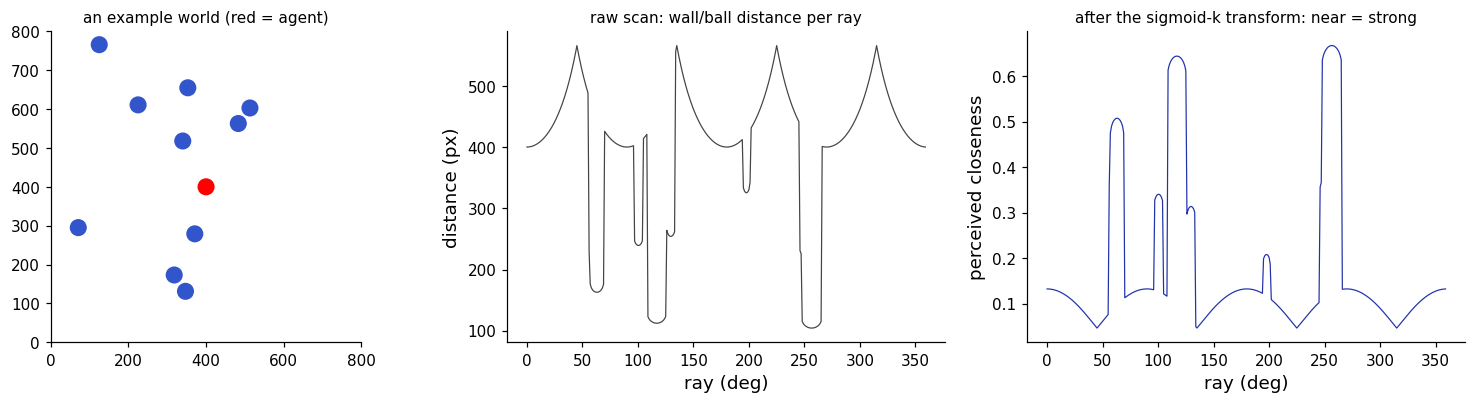

In [3]:
player, balls = make_world(10, W, H)
distances, _ = lidar_scan(player, balls, W, H, 360)
demo = GoalEs2Model(num_features=360)          # untrained: for the transform shape
with torch.no_grad():
    sensed = demo.spatial_sense_block.sigmoid(torch.tensor(distances)).numpy()

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
axes[0].add_patch(plt.Circle((player.x, player.y), player.radius, color="red"))
for b in balls:
    if b is not player:
        axes[0].add_patch(plt.Circle((b.x, b.y), b.radius, color="#3355cc"))
axes[0].set_xlim(0, W); axes[0].set_ylim(0, H); axes[0].set_aspect(1)
axes[0].set_title("an example world (red = agent)", fontsize=10)
axes[1].plot(distances, color="#444444", lw=0.8)
axes[1].set_xlabel("ray (deg)"); axes[1].set_ylabel("distance (px)")
axes[1].set_title("raw scan: wall/ball distance per ray", fontsize=10)
axes[2].plot(sensed, color=C_ES2, lw=0.8)
axes[2].set_xlabel("ray (deg)"); axes[2].set_ylabel("perceived closeness")
axes[2].set_title("after the sigmoid-k transform: near = strong", fontsize=10)
plt.tight_layout()
plt.show()

### 2b. The obstacle field `f_S(S)`: proximity and looming

One number per direction has to answer two questions: *how close* is
something, and is it *approaching*? The obstacle field builds two
per-ray channels and maps them to a single value with a small shared
MLP:

    obstacle(direction) = MLP([proximity, looming])
      proximity = closeness_now
      looming   = (closeness_now - closeness_before) * closeness_now

- **Proximity** (`closeness_now`): how close something is right now —
  a static standoff signal, near = strong.
- **Looming** (`(closeness_now - closeness_before) * closeness_now`):
  the change in closeness (approach), gated by current closeness so that
  approach only counts where something is already near.

The two form a two-channel salience source `[proximity, looming]`,
combined by a learned function — a small MLP applied per ray with
shared weights — rather than by a fixed linear weighting. This is the
salience-side analog of the goal/history gain curves (a learned transfer
function from sensed physics to signal strength), and it is the direct
nonlinear generalization of a plain weighted sum
`w_C*proximity + w_L*looming`, which it can represent as a special case.
On the expert demonstrations it fits markedly better than that linear
combiner and, at matched goal throughput, collides less across the
demonstrated and stress regimes (`RESULTS_goal_es2.md`). (The plot below
uses the untrained model — random MLP weights — so it shows the raw
two-channel mix before training.)

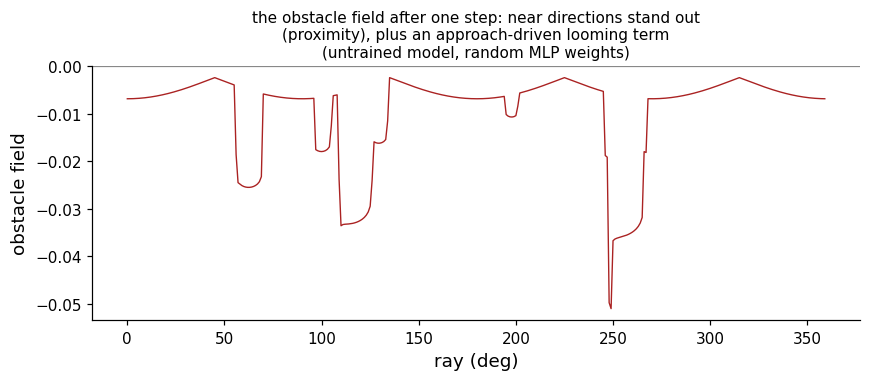

In [4]:
for b in balls:
    if b is not player:
        b.move()
distances2, _ = lidar_scan(player, balls, W, H, 360)
with torch.no_grad():
    obs_field = demo.spatial_sense_block(
        torch.tensor(distances + distances2, dtype=torch.float32).unsqueeze(0)
    )[0].numpy()

plt.figure(figsize=(9, 3))
plt.plot(obs_field, color=C_HAZARD, lw=0.9)
plt.axhline(0, color=C_GRAY, lw=0.8)
plt.xlabel("ray (deg)"); plt.ylabel("obstacle field")
plt.title("the obstacle field after one step: near directions stand out\n"
          "(proximity), plus an approach-driven looming term\n"
          "(untrained model, random MLP weights)",
          fontsize=10)
plt.show()

### 2c. The goal field `f_G(G)`: a pull pattern over directions

The goal is one location; the field turns it into a value for every
one of the 360 ray directions:

    goal_field(ray) = gain(goal distance) * cos(ray - direction to the goal)

Two factors, two jobs:

- **The cosine is the geometry of pull.** "Direction to the goal" is
  the angle of the agent-to-goal vector (what navigators call the
  bearing) — nothing to do with which way the agent is currently
  moving. Each ray gets the cosine of the angle between *that ray*
  and the agent-to-goal direction: +1 on the ray pointing straight at
  the goal, fading to 0 sideways, −1 directly behind. Move the agent
  and the whole pattern rotates to keep its peak on the goal.
- **The gain sets how hard the pattern pulls.** It is one learned
  number (a tiny MLP of goal distance) multiplying the whole cosine
  pattern — the relevance of a goal at that distance. What training
  actually makes of it (Sec. 4): near-zero magnitude right at the goal
  — the pull releases as the agent arrives — rising to full strength
  within a few tens of pixels and constant at any farther distance.
  (Its learned sign is arbitrary: the planner downstream learns the
  matching convention, so magnitude is what carries meaning.)

Below: one fixed goal and three hypothetical agent positions. Each
position has its own bearing to the goal, so each gets a cosine
pattern peaking at a different ray; their distances set the gain.


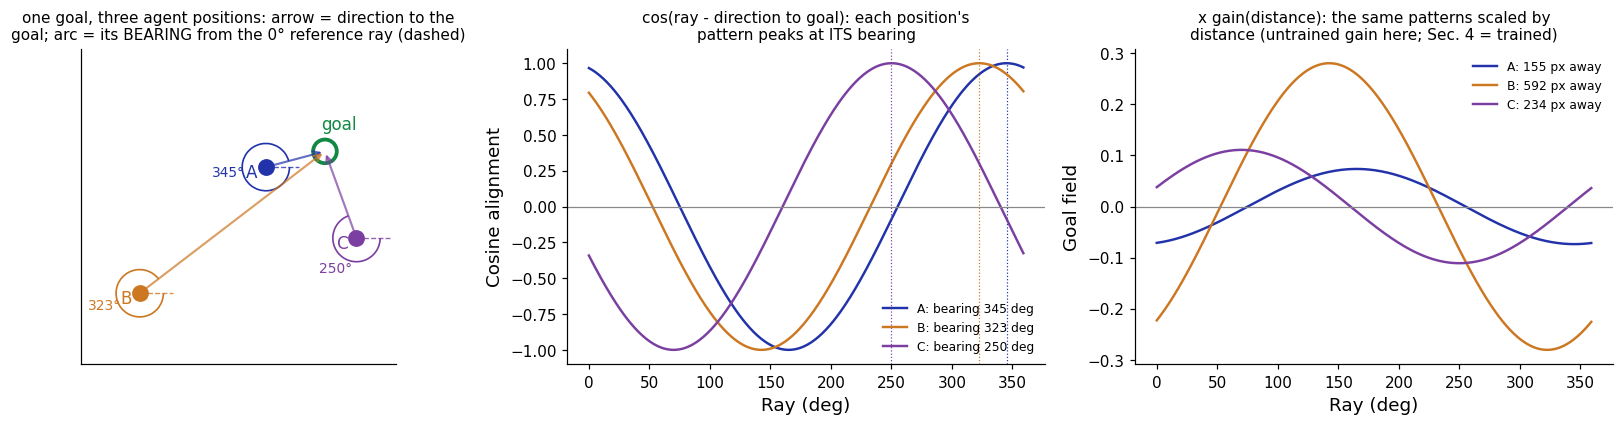

In [5]:
from matplotlib.patches import Arc

GOAL = (620, 260)
agents = {"A (near)": (470, 300), "B (far)": (150, 620),
          "C (other side)": (700, 480)}
acolors = {"A (near)": C_ES2, "B (far)": C_MLP, "C (other side)": "#7a3fa0"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.0))
ax = axes[0]
ax.add_patch(plt.Circle(GOAL, 30, fc="none", ec=C_GOAL, lw=2.5))
ax.annotate("goal", GOAL, (GOAL[0] - 10, GOAL[1] - 55), color=C_GOAL,
            fontsize=11)
for name, (x, y) in agents.items():
    ax.plot(x, y, "o", color=acolors[name], ms=10)
    ax.annotate("", xy=GOAL, xytext=(x, y),
                arrowprops=dict(arrowstyle="->", color=acolors[name],
                                lw=1.4, alpha=0.7))
    ax.annotate(name.split()[0], (x, y), (x - 50, y + 25),
                color=acolors[name], fontsize=11)
    # the BEARING: the angle from the 0-deg reference ray (+x, dashed)
    # around to the agent-to-goal direction
    b = math.degrees(math.atan2(GOAL[1] - y, GOAL[0] - x)) % 360
    ax.plot([x, x + 85], [y, y], color=acolors[name], lw=0.9, ls="--",
            alpha=0.8)
    ax.add_patch(Arc((x, y), 120, 120, angle=0, theta1=0, theta2=b,
                     color=acolors[name], lw=1.1))
    la = math.radians(b / 2)
    ax.annotate(f"{b:.0f}°", (x + 95 * math.cos(la), y + 95 * math.sin(la)),
                color=acolors[name], fontsize=9, ha="center", va="center")
ax.set_xlim(0, W); ax.set_ylim(0, H); ax.set_aspect(1)
ax.invert_yaxis()
ax.set_title("one goal, three agent positions: arrow = direction to the\n"
             "goal; arc = its BEARING from the 0° reference ray (dashed)",
             fontsize=10)
ax.set_xticks([]); ax.set_yticks([])

rays = np.arange(360)
for name, (x, y) in agents.items():
    dx, dy = GOAL[0] - x, GOAL[1] - y
    dist = math.hypot(dx, dy)
    bearing = math.degrees(math.atan2(dy, dx)) % 360
    cosine = np.cos(np.deg2rad(rays - bearing))
    axes[1].plot(rays, cosine, color=acolors[name], lw=1.6,
                 label=f"{name.split()[0]}: bearing {bearing:.0f} deg")
    axes[1].axvline(bearing, color=acolors[name], lw=0.8, ls=":")
    with torch.no_grad():
        g = demo.goal_gain(torch.tensor([[dist / demo.sensing_range]]))
    axes[2].plot(rays, (g.item() * cosine), color=acolors[name], lw=1.6,
                 label=f"{name.split()[0]}: {dist:.0f} px away")
axes[1].axhline(0, color=C_GRAY, lw=0.8)
axes[1].set_xlabel("Ray (deg)"); axes[1].set_ylabel("Cosine alignment")
axes[1].set_title("cos(ray - direction to goal): each position's\n"
                  "pattern peaks at ITS bearing", fontsize=10)
axes[1].legend(fontsize=8)
axes[2].axhline(0, color=C_GRAY, lw=0.8)
axes[2].set_xlabel("Ray (deg)"); axes[2].set_ylabel("Goal field")
axes[2].set_title("x gain(distance): the same patterns scaled by\n"
                  "distance (untrained gain here; Sec. 4 = trained)",
                  fontsize=10)
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()


### 2d. The history field `f_H(H)`: the same pull, from remembered locations

The history field reuses the **identical gain-x-cosine construction of
2c** — but its source is not a visible goal, it is **memory**: a leaky
accumulator over an 8x8 grid of the arena in world coordinates. Every
time a goal appears, all weights decay and the goal's cell gets a
boost:

    W *= (1 - eta_H);   W[cell(goal)] += eta_H

`eta_H` is the learning rate and sets the horizon (~1/eta_H goals
remembered); a one-back "previous goal" memory is just `eta_H = 1`.
Storage is **allocentric** — the map is about the world, not about
where the agent stands.

The readout treats **every cell as a faint goal**. For one cell, the
construction is exactly 2c's: the direction from the agent to the
cell's center gives the bearing, the cosine pattern peaks there, and
the SAME `gain(distance)` curve scales it — then everything is
weighted by the cell's accumulated mass `W[c]`. Do that for all 64
cells and sum, and one scalar `beta_H` sets the overall strength:

    history_field = beta_H * sum_c W[c] * gain(dist to c) * cos(ray - direction to c)

So the field pulls toward the memory's mass wherever it is piled up —
a single cell only in the limit where all the mass is in one place.
`eta_H` = how fast memory updates, `W` = what is remembered, `beta_H`
= how much it biases behavior — the exact analog of the search
model's `eta_H` / `H` / `w_H`. One precedence rule: **a visible
goal overrides history** — the history field enters the sum only when
no goal is on screen. (The accumulator lives inside the model:
`update_memory` / `history_field` in `model/goal_es2.py`; cloning
never touches it, so adding or fitting the memory needs no
retraining.)

Below, left to right: the grid after 12 goals biased toward the left;
the 2c geometry applied to ONE example cell (the heaviest); every
cell's weighted contribution; and their sum — the ACTUAL history
field at this agent position.


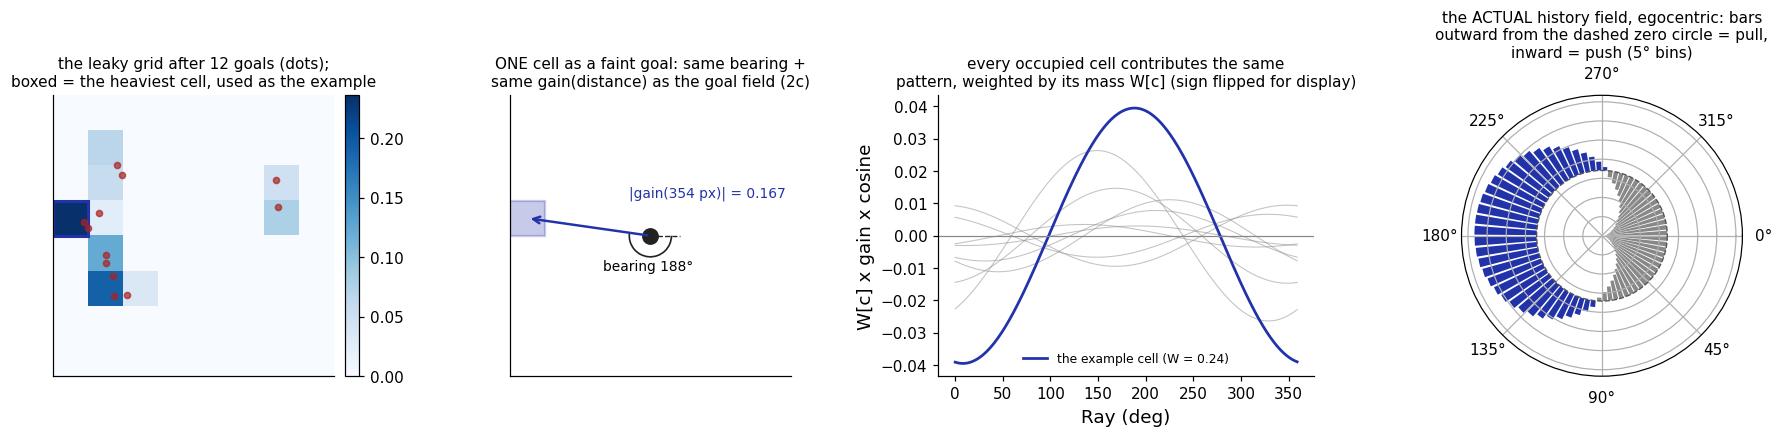

In [6]:
from matplotlib.patches import Arc, Rectangle

rng = random.Random(7)
demo.eta_H = 0.15
demo.reset_memory(W, H)
goals_demo = []
for _ in range(12):                        # 70% in the LEFT wedge
    ecc = rng.uniform(250, 330)
    if rng.random() < 0.7:
        a = math.pi + rng.uniform(-math.pi / 4, math.pi / 4)
    else:
        a = rng.uniform(-math.pi / 4, math.pi / 4)
    g = (W / 2 + ecc * math.cos(a), H / 2 + ecc * math.sin(a))
    goals_demo.append(g)
    demo.update_memory(g)

memory = demo.memory
centers = demo._centers
BETA_DEMO = 0.2
px, py = W / 2, H / 2                      # the agent, at center
k_star = int(memory.argmax())              # the heaviest cell: the example
cx, cy = centers[k_star].tolist()

fig, axes = plt.subplots(1, 4, figsize=(17, 4.0))

ax = axes[0]
im = ax.imshow(memory.reshape(8, 8), cmap="Blues", origin="upper",
               extent=[0, W, H, 0])
for g in goals_demo:
    ax.plot(g[0], g[1], "o", ms=4, color=C_HAZARD, alpha=0.7)
ax.add_patch(Rectangle((cx - 50, cy - 50), 100, 100, fc="none",
                       ec=C_ES2, lw=2))
ax.set_title("the leaky grid after 12 goals (dots);\n"
             "boxed = the heaviest cell, used as the example", fontsize=10)
ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)

# --- one cell, the 2c geometry: bearing arc + gain(distance) ---
ax = axes[1]
dist = math.hypot(cx - px, cy - py)
b = math.degrees(math.atan2(cy - py, cx - px)) % 360
ax.plot(px, py, "o", color="#222222", ms=10)
ax.add_patch(Rectangle((cx - 50, cy - 50), 100, 100, fc=C_ES2, alpha=0.25,
                       ec=C_ES2, lw=1.5))
ax.annotate("", xy=(cx, cy), xytext=(px, py),
            arrowprops=dict(arrowstyle="->", color=C_ES2, lw=1.6))
ax.plot([px, px + 85], [py, py], color="#222222", lw=0.9, ls="--")
ax.add_patch(Arc((px, py), 120, 120, angle=0, theta1=0, theta2=b,
                 color="#222222", lw=1.1))
la = math.radians(b / 2)
ax.annotate(f"bearing {b:.0f}°", (px + 100 * math.cos(la),
                                  py + 100 * math.sin(la)),
            fontsize=9, ha="center")
with torch.no_grad():
    g_here = demo.goal_gain(torch.tensor([[dist / demo.sensing_range]])).item()
# the untrained gain's sign is arbitrary (the planner learns the
# convention - see 2c); flip for display so pull plots as positive
SFLIP = -1.0 if g_here < 0 else 1.0
ax.annotate(f"|gain({dist:.0f} px)| = {abs(g_here):.3f}",
            (px - 60, py - 110), color=C_ES2, fontsize=9, ha="left")
ax.set_xlim(0, W); ax.set_ylim(0, H); ax.set_aspect(1); ax.invert_yaxis()
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("ONE cell as a faint goal: same bearing +\n"
             "same gain(distance) as the goal field (2c)", fontsize=10)

# --- every cell's weighted contribution, then the sum ---
rays = np.arange(360)
vec = centers - torch.tensor([px, py], dtype=torch.float32)
with torch.no_grad():
    Gall = demo.geometric_field(vec, demo.goal_gain)       # (64, 360)
contrib = SFLIP * (memory.unsqueeze(1) * Gall).numpy()
ax = axes[2]
for c in range(64):
    if memory[c] > 0 and c != k_star:
        ax.plot(rays, contrib[c], color=C_GRAY, lw=0.7, alpha=0.5)
ax.plot(rays, contrib[k_star], color=C_ES2, lw=1.8,
        label=f"the example cell (W = {memory[k_star]:.2f})")
ax.axhline(0, color=C_GRAY, lw=0.8)
ax.set_xlabel("Ray (deg)"); ax.set_ylabel("W[c] x gain x cosine")
ax.set_title("every occupied cell contributes the same\n"
             "pattern, weighted by its mass W[c] (sign flipped for display)",
             fontsize=10)
ax.legend(fontsize=8)


def polar_hist(ax, v, col, bin_deg=5):
    """Circular histogram of a 360-ray field: 5-degree bins (the bin's
    extreme value), bars OUTWARD from the dashed zero circle = positive
    (pull), INWARD = negative (push)."""
    nb_ = 360 // bin_deg
    binned = np.zeros(nb_)
    for k in range(nb_):
        seg = v[k * bin_deg:(k + 1) * bin_deg]
        binned[k] = seg[np.argmax(np.abs(seg))]
    r0 = 1.05 * np.abs(v).max() + 1e-9
    ang_ = np.deg2rad(np.arange(nb_) * bin_deg + bin_deg / 2)
    wd_ = np.deg2rad(bin_deg) * 0.8
    pos, neg = binned >= 0, binned < 0
    ax.bar(ang_[pos], binned[pos], width=wd_, bottom=r0, color=col)
    ax.bar(ang_[neg], -binned[neg], width=wd_,
           bottom=r0 + binned[neg], color=C_GRAY)
    th = np.linspace(0, 2 * np.pi, 200)
    ax.plot(th, np.full_like(th, r0), ls="--", color="#555555", lw=0.9)
    ax.set_ylim(0, 2.15 * r0)
    ax.set_theta_zero_location("E"); ax.set_theta_direction(-1)
    ax.set_yticklabels([])

axes[3].remove()
ax = fig.add_subplot(1, 4, 4, projection="polar")
hf = SFLIP * BETA_DEMO * demo.history_field((px, py))[0].numpy()
polar_hist(ax, hf, C_ES2)
ax.set_title("the ACTUAL history field, egocentric: bars\n"
             "outward from the dashed zero circle = pull,\n"
             "inward = push (5° bins)", fontsize=10)
plt.tight_layout()
plt.show()


### 2e. The actual fields, one scene

2a-2d showed the pieces. Here they are computed for real, in one
scene: the example world of 2a, one visible goal, and 2d's memory —
each field exactly as the model computes it, and their sum, the
**priority field the planner reads** — drawn the way the agent has
them: **egocentric roses**, the agent at the center, one value per
ray direction (0° = east, angles clockwise to match the arena's
screen coordinates). The colored lobe is the positive part of the
field (pull toward those directions), the gray lobe the negative part
(push away); the radius is the magnitude. These fields are 1-D over
direction — a 360° panorama, not a 2-D map: distance lives in the
lobes' size, not in a radial axis. (Weights still untrained here,
so the shapes, not the magnitudes, are the point — and the goal and
history lobes are sign-flipped for display as in 2d, so pull points
at the source; Sec. 4-5 show the
trained model acting on the trained version of this sum. And by the
precedence rule, with a goal visible the history row would actually
be gated off — it is drawn here to show all three at once.)


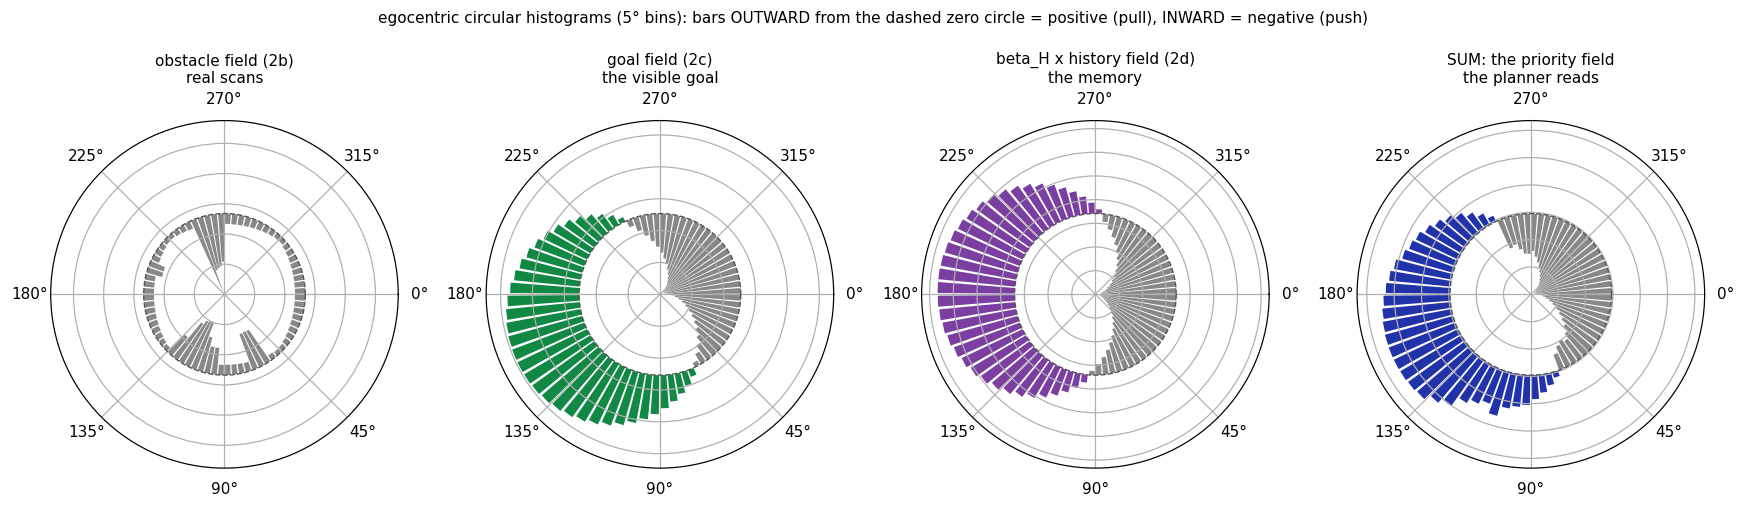

In [7]:
goal_vec = (goals_demo[-1][0] - px, goals_demo[-1][1] - py)
obs = torch.tensor(distances + distances2 + list(goal_vec),
                   dtype=torch.float32).unsqueeze(0)
with torch.no_grad():
    f_obs, f_goal = demo.compute_fields(obs)
# SFLIP (from 2d): the untrained gain's sign is arbitrary; flip the
# gain-based fields for display so pull lobes point at their sources
f_goal = SFLIP * f_goal
f_hist = SFLIP * BETA_DEMO * demo.history_field((px, py))
f_sum = f_obs + f_goal + f_hist

fig, axes = plt.subplots(1, 4, figsize=(16, 4.4),
                         subplot_kw=dict(projection="polar"))
for ax, f, name, col in [
        (axes[0], f_obs, "obstacle field (2b)\nreal scans", C_HAZARD),
        (axes[1], f_goal, "goal field (2c)\nthe visible goal", C_GOAL),
        (axes[2], f_hist, "beta_H x history field (2d)\nthe memory", "#7a3fa0"),
        (axes[3], f_sum, "SUM: the priority field\nthe planner reads", C_ES2)]:
    polar_hist(ax, f[0].numpy(), col)
    ax.set_title(name, fontsize=10)
plt.suptitle("egocentric circular histograms (5° bins): bars OUTWARD from "
             "the dashed zero circle = positive (pull), INWARD = negative "
             "(push)", fontsize=10, y=1.02)
plt.tight_layout()
plt.show()


## 3. The whole model in five lines

Not a re-implementation — the actual forward pass, imported from
`model/goal_es2.py`:

In [8]:
import inspect
print(inspect.getsource(GoalEs2Model.compute_fields))
print(inspect.getsource(GoalEs2Model.forward))

    def compute_fields(self, input):
        scan_input = input[:, : 2 * self.num_features]
        goal = input[:, 2 * self.num_features :]

        obstacle_field = self.spatial_sense_block(scan_input)
        goal_field = self.geometric_field(goal, self.goal_gain)
        return obstacle_field, goal_field

    def forward(self, input, history_field=None):
        obstacle_field, goal_field = self.compute_fields(input)
        field = obstacle_field + goal_field
        if history_field is not None:
            field = field + self.beta_H * history_field
        return self.sense_action_layers(field)



## 5. Training loss: one recipe, three architectures

The field model is not evaluated alone. The repository's two
goal-conditioned baselines — an MLP over the raw 722-vector and a
transformer that treats it as a token sequence — were trained on the
**same** 12,000 demonstrations with the **same** recipe (batch 64, Adam,
MSE, 500 epochs), and are compared against the field model throughout
Sections 5–7. We begin with the training loss itself — the behavioral-cloning MSE: how closely each
architecture reproduces the expert's moves on the training data. (The
transformer needed a GPU — L40S, ~38 h projected on CPU — so its
wall-clock is not hardware-comparable; the loss-by-epoch axis is.)

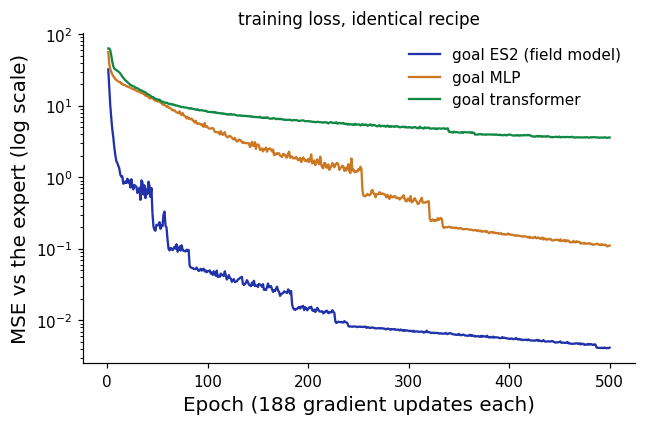

final training MSE:   goal ES2 (field model) 0.004   goal transformer 3.593   goal MLP 0.111


In [9]:
# The field model (ES2) and its two baselines (MLP, transformer), trained on
# the same demonstrations with the same recipe. This cell loads the shared data
# used through Sections 5-7: per-model training-loss curves and the 20-seed
# rollout sweeps (results_compare/). No training happens in the notebook.
import csv
import glob

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from seaborn.algorithms import bootstrap

colors = {"es2": C_ES2, "mlp": C_MLP, "transformer": C_TRF}
labels = {"es2": "goal ES2 (field model)", "mlp": "goal MLP",
          "transformer": "goal transformer"}

loss = {m: [float(r["loss"]) for r in
            csv.DictReader(open(f"results_compare/loss_goal_{m}.csv"))]
        for m in colors}
sw = pd.concat(pd.read_csv(f) for f in glob.glob("results_compare/sweep_*.csv"))

def boot_ci(v):
    bs = bootstrap(np.asarray(v, float), func=np.mean, n_boot=10000, seed=0)
    return np.mean(v), *np.percentile(bs, [2.5, 97.5])

loss_long = pd.DataFrame([{"model": labels[m], "epoch": e + 1, "loss": v}
                          for m in colors for e, v in enumerate(loss[m])])
fig, ax = plt.subplots(figsize=(6, 4))
sns.lineplot(data=loss_long, x="epoch", y="loss", hue="model",
             palette={labels[m]: colors[m] for m in colors}, lw=1.5, ax=ax)
ax.set_yscale("log")
ax.set_xlabel("Epoch (188 gradient updates each)", fontsize=13)
ax.set_ylabel("MSE vs the expert (log scale)", fontsize=13)
ax.set_title("training loss, identical recipe", fontsize=11)
ax.legend(title=None)
plt.tight_layout()
plt.show()

print("final training MSE:   " + "   ".join(
    f"{labels[m]} {loss[m][-1]:.3f}" for m in ["es2", "transformer", "mlp"]))

## 6. Performance on the demonstrated task

Does lower loss mean better behavior? We roll each agent out on the task
it was trained on — 10 balls at the training speed, a persistent world
with a new goal on every arrival — and score **goals per minute** (how
much it gets done) and **collisions per minute** (how safely), against
the scripted expert's own 65.8 and 0.0. Each number is 20 seeds, and the
same seeds drive every agent, so we compare the field model against each
baseline with a paired t-test and Cohen's d (pooled).

trained regime (10 balls, 1x), 20 seeds, mean [bootstrap 95% CI]:
  goal ES2 (field model)   goals  60.6 [58.5, 62.6]   coll 0.20 [0.00, 0.55]


  goal transformer         goals  53.4 [50.9, 56.0]   coll 0.23 [0.00, 0.60]


  goal MLP                 goals  36.5 [34.3, 38.6]   coll 5.05 [3.73, 6.47]
  scripted expert          goals  65.8               coll 0.00

field (ES2) vs each baseline (paired t-test, Cohen's d, 20 seeds):
  goals_per_min      vs transformer  t(19) =   6.17, p = 6.2e-06, Cohen's d = +1.33
  goals_per_min      vs mlp          t(19) =  21.63, p = 7.6e-15, Cohen's d = +4.93
  collisions_per_min vs transformer  t(19) =  -0.11, p = 9.2e-01, Cohen's d = -0.03
  collisions_per_min vs mlp          t(19) =  -7.44, p = 4.9e-07, Cohen's d = -2.06


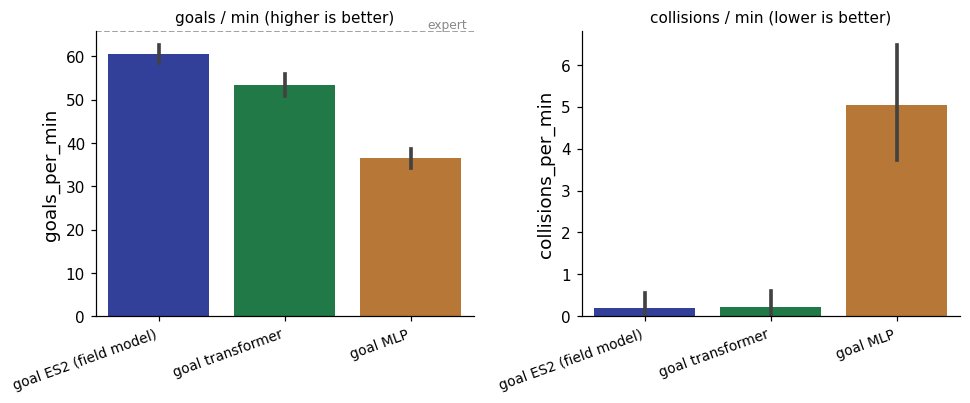

In [10]:
# Trained-regime rollout (10 balls, 1x), 20 seeds. The same seeds drive every
# model (each seed = one world), so field vs baseline is a paired comparison
# (pingouin); effect size is Cohen's d (pooled, signed by the t-statistic),
# matching the search notebook.
import pingouin as pg

def arm(model, balls, speed, metric):
    d = sw[(sw.model == model) & (sw.num_balls == balls)
           & (np.isclose(sw.speed_multiplier, speed))]
    return d.sort_values("seed")[metric].to_numpy()

def paired(a, b):
    r = pg.ttest(a, b, paired=True)
    t, p = r["T"].iloc[0], r["p_val"].iloc[0]
    d = np.copysign(r["cohen_d"].iloc[0], t)   # pingouin's cohen_d is unsigned
    return t, p, d

print("trained regime (10 balls, 1x), 20 seeds, mean [bootstrap 95% CI]:")
for m in ["es2", "transformer", "mlp"]:
    gm, gl, gh = boot_ci(arm(m, 10, 1.0, "goals_per_min"))
    cm, cl, ch = boot_ci(arm(m, 10, 1.0, "collisions_per_min"))
    print(f"  {labels[m]:<24} goals {gm:5.1f} [{gl:.1f}, {gh:.1f}]   "
          f"coll {cm:4.2f} [{cl:.2f}, {ch:.2f}]")
print(f"  {'scripted expert':<24} goals  65.8               coll 0.00")

print("\nfield (ES2) vs each baseline (paired t-test, Cohen's d, 20 seeds):")
for metric in ["goals_per_min", "collisions_per_min"]:
    f = arm("es2", 10, 1.0, metric)
    for base in ["transformer", "mlp"]:
        t, p, d = paired(f, arm(base, 10, 1.0, metric))
        print(f"  {metric:18} vs {base:11}  t(19) = {t:6.2f}, p = {p:.1e}, "
              f"Cohen's d = {d:+.2f}")

# the three agents at the demonstrated setting; seaborn bars = mean,
# whiskers = bootstrap 95% CI over the 20 per-seed rows
demo = sw[(sw.num_balls == 10) & (sw.speed_multiplier == 1.0)]
order = ["es2", "transformer", "mlp"]
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
for ax, metric, ttl in [(axes[0], "goals_per_min", "goals / min (higher is better)"),
                        (axes[1], "collisions_per_min", "collisions / min (lower is better)")]:
    sns.barplot(data=demo, x="model", y=metric, order=order, hue="model",
                hue_order=order, palette=colors, errorbar=("ci", 95),
                n_boot=10000, seed=0, legend=False, ax=ax)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([labels[m] for m in order], rotation=20, ha="right", fontsize=9)
    ax.set_title(ttl, fontsize=10); ax.set_xlabel(""); ax.set_ylim(bottom=0)
axes[0].axhline(65.8, color=C_GRAY, ls="--", lw=1)
axes[0].text(2.45, 65.8, "expert", color=C_GRAY, fontsize=8, va="bottom", ha="right")
plt.tight_layout()
plt.show()

## 7. Scaling to denser and faster scenes

The demonstrations contain exactly one regime: 10 balls at speeds 1-3
px/step. Two stress axes probe what the learned field does outside it,
with no retraining:

- **Density**: from 10 up to 50 balls, several times the crowding ever
  demonstrated.
- **Speed**: every ball's velocity multiplied, up to 4x.

Each sweep condition is 20 seeds; the bands are bootstrap 95% CIs.

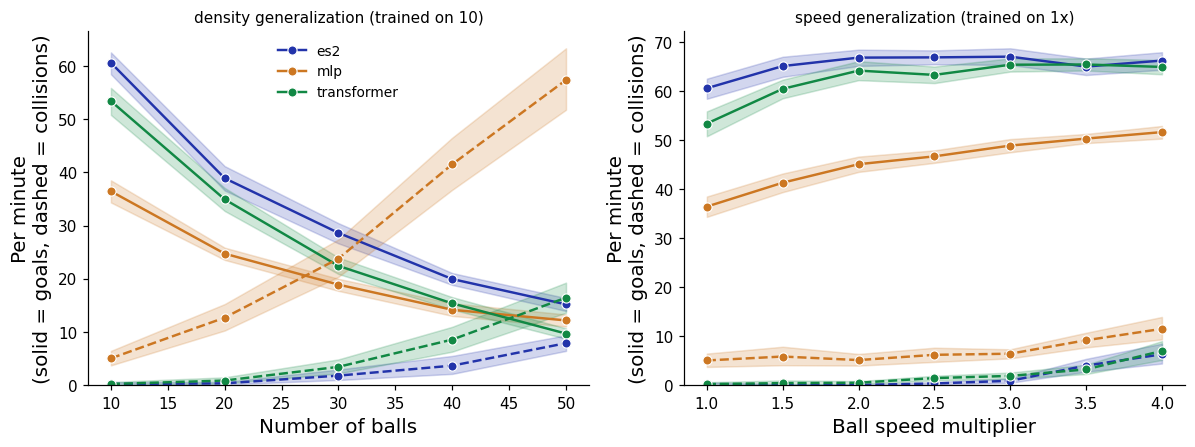

field (ES2) vs each baseline under stress (paired t-test, Cohen's d, 20 seeds):
  dense (50 balls, 1x):
    goals_per_min      vs transformer  t(19) =   9.98, p = 5.5e-09, Cohen's d = +2.13
    goals_per_min      vs mlp          t(19) =   4.22, p = 4.6e-04, Cohen's d = +1.10
    collisions_per_min vs transformer  t(19) =  -4.32, p = 3.7e-04, Cohen's d = -1.60
    collisions_per_min vs mlp          t(19) = -16.12, p = 1.5e-12, Cohen's d = -4.92
  fast (10 balls, 4x):
    goals_per_min      vs transformer  t(19) =   1.52, p = 1.5e-01, Cohen's d = +0.34
    goals_per_min      vs mlp          t(19) =  12.69, p = 1.0e-10, Cohen's d = +3.98
    collisions_per_min vs transformer  t(19) =  -0.84, p = 4.1e-01, Cohen's d = -0.15
    collisions_per_min vs mlp          t(19) =  -4.22, p = 4.6e-04, Cohen's d = -1.01


In [11]:
# Generalization sweeps: density (speed held at 1x) and speed (count held at
# 10), 20 seeds/condition. seaborn draws the mean line + bootstrap 95% CI band
# (solid = goals, dashed = collisions). Reuses sw, colors, arm, paired.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, data, x_key, xlab, ttl in [
        (axes[0], sw[sw.speed_multiplier == 1.0], "num_balls",
         "Number of balls", "density generalization (trained on 10)"),
        (axes[1], sw[sw.num_balls == 10], "speed_multiplier",
         "Ball speed multiplier", "speed generalization (trained on 1x)")]:
    sns.lineplot(data=data, x=x_key, y="goals_per_min", hue="model",
                 hue_order=list(colors), palette=colors, errorbar=("ci", 95),
                 n_boot=10000, seed=0, marker="o", ax=ax,
                 legend=(ax is axes[0]))
    sns.lineplot(data=data, x=x_key, y="collisions_per_min", hue="model",
                 hue_order=list(colors), palette=colors, errorbar=("ci", 95),
                 n_boot=10000, seed=0, marker="o", linestyle="--",
                 legend=False, ax=ax)
    ax.set_xlabel(xlab, fontsize=13)
    ax.set_ylabel("Per minute\n(solid = goals, dashed = collisions)", fontsize=13)
    ax.set_title(ttl, fontsize=10)
    ax.set_ylim(bottom=0)
    if ax is axes[0]:
        ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("field (ES2) vs each baseline under stress (paired t-test, Cohen's d, 20 seeds):")
for label, balls, speed in [("dense (50 balls, 1x)", 50, 1.0),
                            ("fast (10 balls, 4x)", 10, 4.0)]:
    print(f"  {label}:")
    for metric in ["goals_per_min", "collisions_per_min"]:
        f = arm("es2", balls, speed, metric)
        for base in ["transformer", "mlp"]:
            t, p, d = paired(f, arm(base, balls, speed, metric))
            print(f"    {metric:18} vs {base:11}  t(19) = {t:6.2f}, "
                  f"p = {p:.1e}, Cohen's d = {d:+.2f}")

Three readings, honestly stated (rollout numbers are 20 seeds per
condition; the figure bands are bootstrap 95% CIs). First,
imitation loss does not predict rollout: the transformer ends ~850x above
the field model's MSE yet behaves respectably in closed loop (its
per-step errors average out), while the MLP — a much better fit than the
transformer (~26x above the field model) — still hides systematically
unsafe avoidance. Second, what separates the architectures under stress
is **safety**, not throughput — at 50 balls all three land at roughly
10-15 goals/min, but collisions run 7.9 (field), 16.5 (transformer), 57
(MLP) per minute, with non-overlapping CIs between the field model and
each baseline. Third, the field model wins overall — best fit, best
trained-regime throughput (60.6 goals/min vs 53.4 and 36.5, CIs
non-overlapping), most graceful degradation on both axes — while being
the only architecture whose internals are interpretable fields: the
psychophysics of Section 2, the channel decomposition, and the
selection-history mechanism of Section 8 have no analog in the baselines.

## 8. Statistical learning: watch the bias emerge and die

Trials are fixation-start (teleport to center, a 50-step goal-free
window, then the goal) with goals at matched eccentricity: 70% in a
90-degree wedge due-left, 30% in the mirror wedge due-right. Three
stages, computed offline by `evaluate_statistical_learning.py` (20 seeds
per arm, plus a `beta_H = 0` memoryless control) and loaded here — the
same load-and-plot pattern as Section 6:

1. **Teacher**: the trained checkpoint equipped with the grid at ground
   truth `beta* = 0.2, eta* = 0.15` plays the biased task; its
   goal-free behavior is recorded.
2. **Retrain**: a fresh copy with **every network weight frozen**; only
   the two history scalars are trained on those rows, the grid replayed
   differentiably under the candidate `eta` (the agent-side analog of
   the search model's history fitting). Teacher and student share the
   network, so recovery is exact-units.
3. **Deploy**: the fitted student in a world biased for the first 90
   trials and unbiased after — watching the drift bias **emerge** from
   experienced goals and **extinguish** once the statistics change,
   against the `beta_H = 0` memoryless baseline.

recovered: beta_hat = 0.200 (true 0.2), eta_hat = 0.150 (true 0.15), residual MSE 0.014
teacher anticipatory offset: -42.1 px (negative = left; 20 seeds/arm)


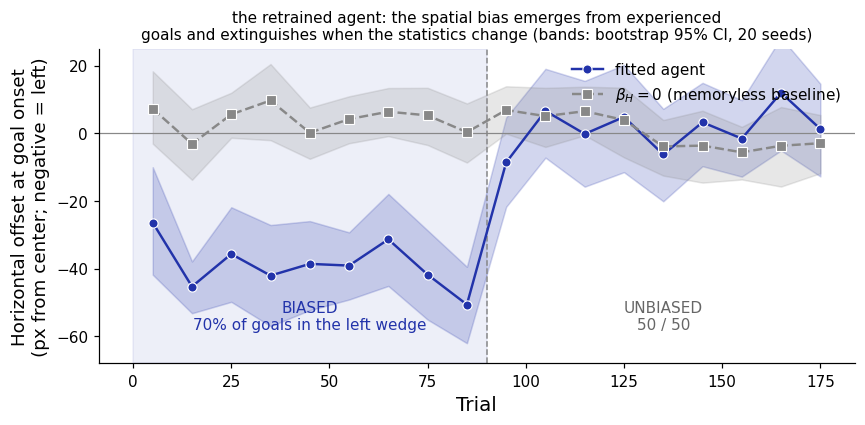

In [12]:
# Section 7 is computed offline by evaluate_statistical_learning.py (20 seeds
# per arm) and written to results_compare/; here we only load and plot with
# seaborn (bootstrap 95% CIs) - the same pattern as the Section 6 comparison.
# No rollouts run in the notebook.
import csv
import pandas as pd

with open("results_compare/statlearn_params.csv") as f:
    P = next(csv.DictReader(f))
beta_hat, eta_hat = float(P["beta_hat"]), float(P["eta_hat"])
fit_mse, teacher_offset = float(P["fit_mse"]), float(P["teacher_offset"])
SWITCH, N_DEP = int(P["switch"]), int(P["deploy_trials"])
BLOCK, SEEDS = int(P["block"]), int(P["num_seeds"])
BETA_STAR, ETA_STAR = float(P["beta_star"]), float(P["eta_star"])

print(f"recovered: beta_hat = {beta_hat:.3f} (true {BETA_STAR}), "
      f"eta_hat = {eta_hat:.3f} (true {ETA_STAR}), residual MSE {fit_mse:.3f}")
print(f"teacher anticipatory offset: {teacher_offset:+.1f} px "
      f"(negative = left; {SEEDS} seeds/arm)")

# Anticipatory measure: the agent's signed horizontal position at goal onset,
# relative to the arena center (px); negative = leftward, toward the biased
# region. Per-seed block means -> long frame; seaborn bootstraps the mean
# across seeds at each trial block (the unit is the seed).
sl = pd.read_csv("results_compare/statlearn_drift.csv")
sl["block"] = (sl["trial"] // BLOCK) * BLOCK + BLOCK / 2   # block-center x
blk = sl.groupby(["arm", "seed", "block"], as_index=False)["offset"].mean()

ARMS = {"fitted": ("fitted agent", C_ES2, "o", "-"),
        "control": (r"$\beta_H = 0$ (memoryless baseline)", C_GRAY, "s", "--")}

fig, ax = plt.subplots(figsize=(8, 4))
ax.axvspan(0, SWITCH, color=C_ES2, alpha=0.08)
ax.axvline(SWITCH, color=C_GRAY, lw=1, ls="--")
ax.axhline(0, color=C_GRAY, lw=0.8)
for arm, (lab, col, mk, ls) in ARMS.items():
    sns.lineplot(data=blk[blk["arm"] == arm], x="block", y="offset",
                 color=col, marker=mk, linestyle=ls, label=lab,
                 errorbar=("ci", 95), n_boot=10000, seed=0, ax=ax)
ax.legend(loc="upper right")
ax.text(SWITCH / 2, -58, "BIASED\n70% of goals in the left wedge",
        ha="center", fontsize=10, color=C_ES2)
ax.text((SWITCH + N_DEP) / 2, -58, "UNBIASED\n50 / 50", ha="center",
        fontsize=10, color="#666666")
ax.set_xlabel("Trial", fontsize=13)
ax.set_ylabel("Horizontal offset at goal onset\n(px from center; negative = left)",
              fontsize=12)
ax.set_ylim(-68, 25)
ax.set_title("the retrained agent: the spatial bias emerges from experienced\n"
             "goals and extinguishes when the statistics change "
             f"(bands: bootstrap 95% CI, {SEEDS} seeds)", fontsize=10)
plt.tight_layout()
plt.show()

In [13]:
# Paired comparison: fitted agent vs the memoryless (beta_H = 0) control.
# The 20 seeds are shared across arms (each seed fixes one world), so the
# comparison is paired (pingouin); the effect size is Cohen's d (pooled,
# signed by the t-statistic), matching the search notebook.
import pingouin as pg

def block_offset(arm, lo, hi):
    a = sl[(sl["arm"] == arm) & (sl["trial"] >= lo) & (sl["trial"] < hi)]
    return a.groupby("seed")["offset"].mean().sort_index().to_numpy()

for name, lo, hi in [("biased block", 1, SWITCH), ("unbiased block", SWITCH, N_DEP)]:
    fit, ctl = block_offset("fitted", lo, hi), block_offset("control", lo, hi)
    r = pg.ttest(fit, ctl, paired=True)
    t, p, dof = r["T"].iloc[0], r["p_val"].iloc[0], int(r["dof"].iloc[0])
    d = np.copysign(r["cohen_d"].iloc[0], t)
    print(f"{name:14}: fitted {fit.mean():+6.1f} px vs control {ctl.mean():+6.1f} px   "
          f"paired t({dof}) = {t:6.2f}, p = {p:.1e}, Cohen's d = {d:+.2f}")

biased block  : fitted  -39.1 px vs control   +4.0 px   paired t(19) = -16.48, p = 1.0e-12, Cohen's d = -4.37
unbiased block: fitted   +1.3 px vs control   +0.3 px   paired t(19) =   0.30, p = 7.6e-01, Cohen's d = +0.07


Three results in one chain (ledger, `evaluate_statistical_learning.py`).
**Recovery is exact**: with the network frozen, the two history scalars
fitted on the teacher's goal-free drift land on the generating values
(the ledger record: 0.200 / 0.150; the residual MSE is integer-stepping
noise) — the parameters are identifiable from behavior, as in the
search model's fits. **The bias emerges**: deployed in the biased
world, the fitted agent's goal-free drift toward the likely region
builds within the first several trials (the grid fills fast at
`eta = 0.15`) to a ~40 px leftward offset from center by goal onset,
purely from experienced goal locations — the grid starts empty (biased block: paired *t*(19) = −16.5, *p* < .001, Cohen's *d* = 4.37 versus the memoryless control). **And it
extinguishes**: after the switch to unbiased statistics the learned
drift decays within ~1/eta goals down to the gray `beta_H = 0`
baseline — the memoryless policy's own goal-free residual, which is
not exactly zero because the zero-goal input never occurs in the
cloning data, so the network's output there is unconstrained (a small
push, mostly downward, whose closed-loop horizontal component comes
out slightly rightward). Extinguished means indistinguishable from
the memoryless agent, and that baseline — not the zero line — is the
comparison (after the switch the two agents no longer differ: *t*(19) = 0.30, *p* = .76, *d* = 0.07). It is genuinely statistical learning, not priming
in disguise: on trials where the previous goal fell in the unlikely
wedge, the grid agent still drifts toward the likely region while the
one-back trace (the `eta = 1` case) drifts the wrong way (ledger).
Honest boundaries: the mechanism is endowed and its parameters fitted
— the statistics are what is acquired; and human location-probability
cueing extinguishes far more slowly than a single-eta leak (Jiang's
persistence findings), so habit-like persistence would need a second,
slower accumulator.

## Recap

| The agent receives | It returns |
| --- | --- |
| two LiDAR scans, the goal vector, the remembered-goal vector | a 2D movement |

We introduced the field model and its diagram (Sec. 1), built the
pieces - distance psychophysics, looming, the gain-x-cosine goal and
history fields (Sec. 2) - showed the whole forward pass imported from
the codebase (Sec. 3), cloned the expert with history disabled
(Sec. 4), compared training loss across the field model and its two
baselines (Sec. 5), matched the expert's throughput on the demonstrated
task and out-scored both baselines (Sec. 6), probed never-demonstrated
densities and speeds (Sec. 7),
and closed the chain on selection history: a leaky world-grid memory
whose two parameters are recoverable from demonstrations with the
policy frozen, and whose deployment shows a spatial bias emerging from
experienced goal statistics and extinguishing when they change
(Sec. 8; the one-back priming demonstration it generalizes is recorded
in the ledger and `evaluate_priming.py`).

More: `RESULTS_goal_es2.md` (the full experimental record for
this model) and `Visual-Search/tutorial_visual_search.ipynb` (the
companion model of first saccades).